# ResNet-UNet Model Training

## Import Libraries and Shared Utilities

In [2]:
import sys
import os
import tensorflow as tf
from tensorflow import keras
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# Add parent directory to path to import utils
parent_dir = str(Path.cwd().parent)
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print(f"Utils path: {parent_dir}")
print(f"Utils file exists: {os.path.exists(os.path.join(parent_dir, 'utils.py'))}\n")

# Import shared utility functions
try:
    from utils import (
        load_image_dataset,
        normalize,
        augment_image,
        load_dataset_with_info,
        BASE_PATH,
        IMAGE_SIZE
    )
    print(f"✅ Successfully imported from utils.py")
except ImportError as e:
    print(f"❌ Import Error: {e}")
    print(f"   Current directory: {Path.cwd()}")
    print(f"   Parent directory: {parent_dir}")
    print(f"   Python path: {sys.path[:3]}...")
    raise


Utils path: /Users/abhishekpanthee/Documents/hackathon/ml-app
Utils file exists: True

✅ Successfully imported from utils.py


## Load and Prepare Datasets

Using shared `load_dataset_with_info` function from utils.py

In [3]:
# Configuration - Use smaller batch to prevent OOM
BATCH_SIZE = 8  # Reduced further to prevent crashes
IMAGE_SIZE = 224

# Enable memory growth for GPU to prevent OOM
gpus = tf.config.experimental.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU memory growth enabled for {len(gpus)} GPU(s)")
    except RuntimeError as e:
        print(f"⚠️ GPU config error: {e}")
else:
    print("⚠️ No GPU detected - running on CPU (will be slow)")

# Clear any existing models from memory
tf.keras.backend.clear_session()
import gc
gc.collect()

print(f"Dataset Base Path: {BASE_PATH}")
print(f"Path exists: {BASE_PATH.exists()}\n")

# ============================================================
# LAZY LOADING: Generator-based dataset that loads images on-demand
# Uses .repeat() to allow multiple epochs
# ============================================================
from PIL import Image

def create_lazy_dataset(split, category, base_path, batch_size=8, image_size=224):
    """
    Creates a tf.data.Dataset that lazily loads images batch-by-batch.
    Images are only loaded into memory when needed, preventing OOM errors.
    """
    full_path = Path(base_path) / split / category
    
    if not full_path.exists():
        print(f"❌ {split}/{category}: Path not found - {full_path}")
        return None, 0
    
    # Get file paths (not images themselves - lazy!)
    valid_extensions = ['.tif', '.jpg', '.png', '.jpeg', '.bmp', '.gif']
    file_paths = [str(f) for f in full_path.glob('*') if f.suffix.lower() in valid_extensions]
    file_count = len(file_paths)
    
    print(f"✅ {split:5s}/{category:4s}: {file_count:4d} images (lazy loading)")
    
    def image_generator():
        """Generator that yields one image at a time"""
        for file_path in file_paths:
            try:
                with Image.open(file_path) as img:
                    # Convert to RGB (handles grayscale/RGBA)
                    if category == 'Mask':
                        img = img.convert('L')  # Grayscale for masks
                        img = img.resize((image_size, image_size))
                        arr = np.array(img, dtype=np.float32) / 255.0
                        arr = np.expand_dims(arr, axis=-1)  # (H, W, 1)
                    else:
                        img = img.convert('RGB')
                        img = img.resize((image_size, image_size))
                        arr = np.array(img, dtype=np.float32) / 255.0  # (H, W, 3)
                    yield arr
            except Exception as e:
                print(f"⚠️ Skipping {file_path}: {e}")
                continue
    
    # Define output shape based on category
    if category == 'Mask':
        output_sig = tf.TensorSpec(shape=(image_size, image_size, 1), dtype=tf.float32)
    else:
        output_sig = tf.TensorSpec(shape=(image_size, image_size, 3), dtype=tf.float32)
    
    # Create dataset from generator
    dataset = tf.data.Dataset.from_generator(
        image_generator,
        output_signature=output_sig
    )
    
    # Batch and prefetch (images loaded only when batch is requested)
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(buffer_size=1)  # Minimal prefetch
    
    return dataset, file_count

# Load datasets lazily (no images in memory yet!)
print("\n📦 Creating LAZY datasets (images load on-demand):\n")

print("Training Set:")
train_au_ds, train_au_count = create_lazy_dataset('train', 'Au', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
train_tp_ds, train_tp_count = create_lazy_dataset('train', 'Tp', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
train_mask_ds, train_mask_count = create_lazy_dataset('train', 'Mask', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

print("\nTest Set:")
test_au_ds, _ = create_lazy_dataset('test', 'Au', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
test_tp_ds, _ = create_lazy_dataset('test', 'Tp', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
test_mask_ds, _ = create_lazy_dataset('test', 'Mask', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

print("\nValidation Set:")
val_au_ds, _ = create_lazy_dataset('val', 'Au', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
val_tp_ds, _ = create_lazy_dataset('val', 'Tp', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
val_mask_ds, _ = create_lazy_dataset('val', 'Mask', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

print("\n" + "="*60)
print("✅ ALL LAZY DATASETS CREATED!")
print(f"   Batch size: {BATCH_SIZE}")
print("   Images will load batch-by-batch during training")
print("="*60)

⚠️ No GPU detected - running on CPU (will be slow)
Dataset Base Path: /Users/abhishekpanthee/Documents/hackathon/ml-app/split_dataset
Path exists: True


📦 Creating LAZY datasets (images load on-demand):

Training Set:
✅ train/Au  : 1181 images (lazy loading)
✅ train/Tp  : 3123 images (lazy loading)
✅ train/Mask: 3123 images (lazy loading)

Test Set:
✅ test /Au  :  337 images (lazy loading)
✅ test /Tp  :  862 images (lazy loading)
✅ test /Mask:  862 images (lazy loading)

Validation Set:
✅ val  /Au  :  170 images (lazy loading)
✅ val  /Tp  :  450 images (lazy loading)
✅ val  /Mask:  450 images (lazy loading)

✅ ALL LAZY DATASETS CREATED!
   Batch size: 8
   Images will load batch-by-batch during training


## Normalization of images

In [4]:
# Images are already normalized (0-1) in the lazy loader
# No need to normalize again - just verify

print("✅ Images already normalized in lazy loader (divided by 255)")
print("   Skipping separate normalization step to save memory\n")

# Verify by checking a sample batch
print("🔍 Verifying sample batch:")
for batch in train_au_ds.take(1):
    print(f"   Shape: {batch.shape}")
    print(f"   Value range: [{batch.numpy().min():.3f}, {batch.numpy().max():.3f}]")
    print(f"   Dtype: {batch.dtype}")

✅ Images already normalized in lazy loader (divided by 255)
   Skipping separate normalization step to save memory

🔍 Verifying sample batch:
   Shape: (8, 224, 224, 3)
   Value range: [0.000, 1.000]
   Dtype: <dtype: 'float32'>


2026-01-18 01:50:15.164974: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Data Argumentation

In [5]:
# Light augmentation applied per-batch (memory efficient)
def augment_batch(images):
    """Apply augmentation to a batch of images"""
    # Random horizontal flip
    images = tf.image.random_flip_left_right(images)
    # Random brightness
    images = tf.image.random_brightness(images, max_delta=0.2)
    images = tf.clip_by_value(images, 0.0, 1.0)
    # Random contrast
    images = tf.image.random_contrast(images, lower=0.8, upper=1.2)
    images = tf.clip_by_value(images, 0.0, 1.0)
    return images

# Apply augmentation to training datasets (lazy - applied when batch is fetched)
train_au_ds = train_au_ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)
train_tp_ds = train_tp_ds.map(augment_batch, num_parallel_calls=tf.data.AUTOTUNE)

print('✅ Augmentation applied (will execute lazily per batch)')

✅ Augmentation applied (will execute lazily per batch)


## Create Properly Paired Tp-Mask Dataset for Segmentation

The mask filename = `{tampered_filename_without_extension}_gt.png`. We need explicit filename-based pairing to ensure each tampered image is matched with its correct ground truth mask.

In [6]:
import glob
from pathlib import Path
from PIL import Image
import numpy as np

def create_paired_tp_mask_dataset(split, base_path, batch_size=32, image_size=224):
   
    tp_dir = base_path / split / 'Tp'
    mask_dir = base_path / split / 'Mask'
    
    # Get all tampered image files
    tp_files = list(tp_dir.glob('*'))
    tp_files = [f for f in tp_files if f.suffix.lower() in ['.tif', '.jpg', '.png', '.jpeg', '.bmp']]
    
    paired_tp_paths = []
    paired_mask_paths = []
    missing_masks = []
    
    for tp_file in tp_files:
        # Construct expected mask filename: {basename}_gt.png
        tp_basename = tp_file.stem  # filename without extension
        expected_mask_name = f"{tp_basename}_gt.png"
        mask_path = mask_dir / expected_mask_name
        
        if mask_path.exists():
            paired_tp_paths.append(str(tp_file))
            paired_mask_paths.append(str(mask_path))
        else:
            missing_masks.append(tp_file.name)
    
    print(f"\n📁 {split.upper()} Paired Dataset:")
    print(f"   ✅ Successfully paired: {len(paired_tp_paths)} images")
    if missing_masks:
        print(f"   ⚠️  Missing masks for {len(missing_masks)} images")
        if len(missing_masks) <= 5:
            for m in missing_masks:
                print(f"      - {m}")
    
    # Use Python generator with PIL - with proper resource cleanup
    def image_generator():
        for tp_path, mask_path in zip(paired_tp_paths, paired_mask_paths):
            try:
                # Load tampered image with PIL (handles TIFF) - use context manager
                with Image.open(tp_path) as tp_img:
                    tp_img = tp_img.convert('RGB')
                    tp_img = tp_img.resize((image_size, image_size))
                    tp_arr = np.array(tp_img, dtype=np.float32) / 255.0
                
                # Load mask with PIL - use context manager
                with Image.open(mask_path) as mask_img:
                    mask_img = mask_img.convert('L')  # Grayscale
                    mask_img = mask_img.resize((image_size, image_size))
                    mask_arr = np.array(mask_img, dtype=np.float32) / 255.0
                    mask_arr = np.expand_dims(mask_arr, axis=-1)  # Add channel dim
                
                yield tp_arr, mask_arr
            except Exception as e:
                print(f"   ⚠️  Skipping {tp_path}: {e}")
                continue
    
    # Create dataset from generator
    dataset = tf.data.Dataset.from_generator(
        image_generator,
        output_signature=(
            tf.TensorSpec(shape=(image_size, image_size, 3), dtype=tf.float32),
            tf.TensorSpec(shape=(image_size, image_size, 1), dtype=tf.float32)
        )
    )
    
    # Use smaller shuffle buffer to reduce memory usage
    dataset = dataset.shuffle(buffer_size=min(200, len(paired_tp_paths)))
    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    
    return dataset, len(paired_tp_paths)

# Create paired datasets for Stage 2 segmentation training
print("="*60)
print("CREATING PAIRED Tp-MASK DATASETS FOR SEGMENTATION")
print("="*60)

train_paired_ds, train_count = create_paired_tp_mask_dataset('train', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
val_paired_ds, val_count = create_paired_tp_mask_dataset('val', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)
test_paired_ds, test_count = create_paired_tp_mask_dataset('test', BASE_PATH, BATCH_SIZE, IMAGE_SIZE)

print("\n" + "="*60)
print("✅ PAIRED DATASETS CREATED SUCCESSFULLY!")
print(f"   Train: {train_count} | Val: {val_count} | Test: {test_count}")
print("="*60)

# Verify a sample batch
print("\n🔍 Verifying sample batch shapes:")
for tp_batch, mask_batch in train_paired_ds.take(1):
    print(f"   Tampered images: {tp_batch.shape}")
    print(f"   Mask images: {mask_batch.shape}")
    print(f"   Tp value range: [{tp_batch.numpy().min():.3f}, {tp_batch.numpy().max():.3f}]")
    print(f"   Mask value range: [{mask_batch.numpy().min():.3f}, {mask_batch.numpy().max():.3f}]")

CREATING PAIRED Tp-MASK DATASETS FOR SEGMENTATION

📁 TRAIN Paired Dataset:
   ✅ Successfully paired: 3123 images

📁 VAL Paired Dataset:
   ✅ Successfully paired: 450 images

📁 TEST Paired Dataset:
   ✅ Successfully paired: 862 images

✅ PAIRED DATASETS CREATED SUCCESSFULLY!
   Train: 3123 | Val: 450 | Test: 862

🔍 Verifying sample batch shapes:
   Tampered images: (8, 224, 224, 3)
   Mask images: (8, 224, 224, 1)
   Tp value range: [0.000, 1.000]
   Mask value range: [0.000, 1.000]


2026-01-18 01:50:25.523113: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


## Training ResNet-50 Classifier (Authentic vs Tampered)



In [7]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout, BatchNormalization
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam


# Load ResNet-50 pretrained on ImageNet
base_model = ResNet50(
    weights='imagenet',
    include_top=False,
    input_shape=(IMAGE_SIZE, IMAGE_SIZE, 3)
)

print(f"\n ResNet-50 Info:")
print(f"   Total layers: {len(base_model.layers)}")

# Freeze all layers first
for layer in base_model.layers:
    layer.trainable = False

# Unfreeze last 30 layers for fine-tuning
UNFREEZE_LAYERS = 30
for layer in base_model.layers[-UNFREEZE_LAYERS:]:
    layer.trainable = True

trainable_count = sum(1 for layer in base_model.layers if layer.trainable)
frozen_count = len(base_model.layers) - trainable_count
print(f"   Frozen layers: {frozen_count}")
print(f"   Trainable layers: {trainable_count}")

# Add classification head
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)
x = Dense(512, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.3)(x)
x = Dense(1, activation='sigmoid')(x)  # Binary: Authentic (0) vs Tampered (1)

classifier_model = Model(inputs=base_model.input, outputs=x, name='ResNet50_Classifier')

print(f"\n✅ Classifier built!")
print(f"   Output: Binary (0=Authentic, 1=Tampered)")
print(f"   Total params: {classifier_model.count_params():,}")


 ResNet-50 Info:
   Total layers: 175
   Frozen layers: 145
   Trainable layers: 30

✅ Classifier built!
   Output: Binary (0=Authentic, 1=Tampered)
   Total params: 24,776,577


##  Classification Data 

In [8]:
# ============================================================
# TRAINING WITH CORRECT IMAGE SIZE
# ============================================================

from PIL import Image
import numpy as np

def get_paths(split, category):
    path = BASE_PATH / split / category
    exts = ['.tif', '.jpg', '.png', '.jpeg', '.bmp']
    return [str(f) for f in path.glob('*') if f.suffix.lower() in exts]

# Get file paths
train_au = get_paths('train', 'Au')
train_tp = get_paths('train', 'Tp')
val_au = get_paths('val', 'Au')
val_tp = get_paths('val', 'Tp')

print(f"Train: {len(train_au)} Au + {len(train_tp)} Tp")
print(f"Val:   {len(val_au)} Au + {len(val_tp)} Tp")

# Create labeled data lists
train_data = [(p, 0) for p in train_au] + [(p, 1) for p in train_tp]
val_data = [(p, 0) for p in val_au] + [(p, 1) for p in val_tp]

if not train_data or not val_data:
    raise ValueError("Training/validation data could not be loaded. Check dataset paths.")

def load_single_image(path, size):
    """Load and preprocess a single image using PIL for TIFF compatibility."""
    with Image.open(path) as img:
        img = img.convert('RGB').resize((size, size))
        return np.array(img, dtype=np.float32) / 255.0

def _load_image_py(path):
    """Helper for tf.numpy_function to decode bytes -> path string."""
    if isinstance(path, (bytes, np.bytes_)):
        path = path.decode('utf-8')
    elif isinstance(path, np.ndarray):
        path = path.item()
        if isinstance(path, (bytes, np.bytes_)):
            path = path.decode('utf-8')
    return load_single_image(path, IMAGE_SIZE)

def build_classifier_dataset(data, batch_size, training):
    paths = [p for p, _ in data]
    labels = [l for _, l in data]
    dataset = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        shuffle_buf = min(len(paths), 4096)  # cap buffer to avoid RAM spikes
        dataset = dataset.shuffle(buffer_size=shuffle_buf, reshuffle_each_iteration=True)

    def _tf_parse(path, label):
        image = tf.numpy_function(func=_load_image_py, inp=[path], Tout=tf.float32)
        image.set_shape((IMAGE_SIZE, IMAGE_SIZE, 3))
        label = tf.cast(label, tf.float32)
        label = tf.reshape(label, [1])
        return image, label

    dataset = dataset.map(_tf_parse, num_parallel_calls=tf.data.AUTOTUNE)
    dataset = dataset.batch(batch_size, drop_remainder=False)
    dataset = dataset.prefetch(tf.data.AUTOTUNE)
    return dataset

train_ds = build_classifier_dataset(train_data, BATCH_SIZE, training=True)
val_ds = build_classifier_dataset(val_data, BATCH_SIZE, training=False)

# Compile model
classifier_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
 )

print(f"✅ Model compiled")
print(f"   IMAGE_SIZE: {IMAGE_SIZE}")
print(f"   BATCH_SIZE: {BATCH_SIZE}")
print(f"   Steps per epoch: {max(1, len(train_data) // BATCH_SIZE)}")

EPOCHS = 7
print(f"\n🚀 Training ResNet-50 classifier for {EPOCHS} epochs using tf.data...")
print("="*50)

history_classifier = classifier_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    verbose=1
)

print("\n✅ Training complete!")

# FIXED: Save with correct name
# classifier_model.save('resnet50_classifier.keras')
# base_model.save('resnet50_encoder_trained.keras')
print("📁 Models saved: resnet50_classifier.keras, resnet50_encoder_trained.keras")

Train: 1181 Au + 3123 Tp
Val:   170 Au + 450 Tp
✅ Model compiled
   IMAGE_SIZE: 224
   BATCH_SIZE: 8
   Steps per epoch: 538

🚀 Training ResNet-50 classifier for 7 epochs using tf.data...
Epoch 1/7
538/538 ━━━━━━━━━━━━━━━━━━━━ 149s 272ms/step - accuracy: 0.6487 - loss: 0.7567 - val_accuracy: 0.7258 - val_loss: 0.9563
Epoch 2/7
538/538 ━━━━━━━━━━━━━━━━━━━━ 154s 286ms/step - accuracy: 0.6589 - loss: 0.7073 - val_accuracy: 0.7113 - val_loss: 1.0743
Epoch 3/7
538/538 ━━━━━━━━━━━━━━━━━━━━ 157s 292ms/step - accuracy: 0.6715 - loss: 0.6878 - val_accuracy: 0.7258 - val_loss: 0.6607
Epoch 4/7
538/538 ━━━━━━━━━━━━━━━━━━━━ 161s 299ms/step - accuracy: 0.6810 - loss: 0.6711 - val_accuracy: 0.7258 - val_loss: 0.6624
Epoch 5/7
538/538 ━━━━━━━━━━━━━━━━━━━━ 163s 303ms/step - accuracy: 0.6908 - loss: 0.6567 - val_accuracy: 0.7258 - val_loss: 0.6230
Epoch 6/7
538/538 ━━━━━━━━━━━━━━━━━━━━ 166s 309ms/step - accuracy: 0.6956 - loss: 0.6430 - val_accuracy: 0.7258 - val_loss: 0.8476
Epoch 7/7
538/538 ━━━━━━━━

In [9]:
classifier_model.save('resnet50_classifier_7epochs.keras')
base_model.save('resnet50_encoder_trained_7epochs.keras')

## UNet Decoder for Mask Prediction

In [10]:
from tensorflow.keras.layers import Conv2D, Conv2DTranspose, Concatenate, Activation
import tensorflow.keras.backend as K


# Freeze the trained encoder completely
for layer in base_model.layers:
    layer.trainable = False

print(f"✅ Encoder frozen (all {len(base_model.layers)} layers)")

# Get skip connections from encoder
skip_layer_names = ['conv1_relu', 'conv2_block3_out', 'conv3_block4_out', 'conv4_block6_out']
skip_connections = [base_model.get_layer(name).output for name in skip_layer_names]
encoder_output = base_model.output

# Custom loss functions
def dice_coefficient(y_true, y_pred, smooth=1e-6):
    y_true_f = K.flatten(y_true)
    y_pred_f = K.flatten(y_pred)
    intersection = K.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (K.sum(y_true_f) + K.sum(y_pred_f) + smooth)

def dice_loss(y_true, y_pred):
    return 1 - dice_coefficient(y_true, y_pred)

def bce_dice_loss(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    return bce + dice_loss(y_true, y_pred)

# Decoder block
def decoder_block(inputs, skip_features, num_filters):
    x = Conv2DTranspose(num_filters, (2, 2), strides=2, padding='same')(inputs)
    x = BatchNormalization()(x)
    x = Activation('relu')(x)
    x = Concatenate()([x, skip_features])
    x = Conv2D(num_filters, (3, 3), padding='same', activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.3)(x)
    x = Conv2D(num_filters, (3, 3), padding='same', activation='relu')(x)
    return x

# Build decoder
x = encoder_output
x = Conv2DTranspose(512, (2, 2), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Concatenate()([x, skip_connections[3]])
x = Conv2D(512, (3, 3), padding='same', activation='relu')(x)

x = decoder_block(x, skip_connections[2], 256)
x = decoder_block(x, skip_connections[1], 128)
x = decoder_block(x, skip_connections[0], 64)

x = Conv2DTranspose(32, (2, 2), strides=2, padding='same')(x)
x = BatchNormalization()(x)
x = Activation('relu')(x)
x = Conv2D(32, (3, 3), padding='same', activation='relu')(x)

output = Conv2D(1, (1, 1), activation='sigmoid', name='mask_output')(x)

unet_model = Model(inputs=base_model.input, outputs=output, name='ResNet50_UNet')

# Count trainable params (only decoder)
trainable_params = sum([K.count_params(w) for w in unet_model.trainable_weights])
print(f"\n✅ UNet built with trained encoder!")
print(f"   Trainable params (decoder only): {trainable_params:,}")
print(f"   Output shape: {unet_model.output_shape}")

✅ Encoder frozen (all 175 layers)

✅ UNet built with trained encoder!
   Trainable params (decoder only): 15,042,785
   Output shape: (None, 224, 224, 1)


## Train Stage 2: UNet Decoder with Mask Data

In [11]:
# ============================================================
# STAGE 2: TRAINING UNET DECODER WITH TF.DATA PIPELINE
# ============================================================

print("="*60)
print("STAGE 2: TRAINING UNET WITH PAIRED Tp-MASK DATA")
print("="*60)

if train_paired_ds is None or val_paired_ds is None:
    raise ValueError("Paired datasets not found. Re-run the dataset pairing cell above.")

print(f"   Train pairs: {train_count}")
print(f"   Val pairs:   {val_count}")

# Compile UNet
unet_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss=bce_dice_loss,
    metrics=['binary_accuracy', dice_coefficient]
 )
print("✅ UNet compiled with BCE+Dice loss")

EPOCHS_STAGE2 = 12
print(f"\n🚀 STAGE 2: Training decoder for {EPOCHS_STAGE2} epochs using tf.data...")
print("="*60)

history_stage2 = unet_model.fit(
    train_paired_ds,
    validation_data=val_paired_ds,
    epochs=EPOCHS_STAGE2,
    verbose=1
)

print("\n" + "="*60)
print("✅ STAGE 2 COMPLETE!")
print("="*60)

# Save the complete model
unet_model.save('resnet50_unet_tampering_detector.keras')
print("\n📁 Complete UNet model saved: resnet50_unet_tampering_detector.keras")

STAGE 2: TRAINING UNET WITH PAIRED Tp-MASK DATA
   Train pairs: 3123
   Val pairs:   450
✅ UNet compiled with BCE+Dice loss

🚀 STAGE 2: Training decoder for 12 epochs using tf.data...
Epoch 1/12
    391/Unknown 477s 1s/step - binary_accuracy: 0.7427 - dice_coefficient: 0.1220 - loss: 1.3765

2026-01-18 02:18:36.415754: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]
/opt/anaconda3/envs/tf-gpu/lib/python3.11/site-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


391/391 ━━━━━━━━━━━━━━━━━━━━ 506s 1s/step - binary_accuracy: 0.8624 - dice_coefficient: 0.1103 - loss: 1.2663 - val_binary_accuracy: 0.9187 - val_dice_coefficient: 0.0996 - val_loss: 1.2005
Epoch 2/12


2026-01-18 02:19:05.961440: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.9072 - dice_coefficient: 0.1043 - loss: 1.2057

...

391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - binary_accuracy: 0.8827 - dice_coefficient: 0.1596 - loss: 1.1449

2026-01-18 03:59:53.484996: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]


391/391 ━━━━━━━━━━━━━━━━━━━━ 492s 1s/step - binary_accuracy: 0.8818 - dice_coefficient: 0.1493 - loss: 1.1640 - val_binary_accuracy: 0.9131 - val_dice_coefficient: 0.0881 - val_loss: 1.1939


2026-01-18 04:00:20.572920: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
	 [[{{node IteratorGetNext}}]]



✅ STAGE 2 COMPLETE!

📁 Complete UNet model saved: resnet50_unet_tampering_detector.keras


In [12]:
unet_model.save('resnet50_unet_12epochs.keras')
print("📁 Model saved: resnet50_unet_12epochs.keras")

📁 Model saved: resnet50_unet_12epochs.keras


In [13]:
history_stage2

In [14]:
history_stage2.history


{'binary_accuracy': [0.8624058365821838,
  0.9053404927253723,
  0.9053401947021484,
  0.9053409099578857,
  0.9053109884262085,
  0.9042268395423889,
  0.9049717783927917,
  0.8985993266105652,
  0.8919892311096191,
  0.8865998387336731,
  0.8852303624153137,
  0.8817533254623413],
 'dice_coefficient': [0.11030757427215576,
  0.10674938559532166,
  0.11153043061494827,
  0.11747458577156067,
  0.12715621292591095,
  0.13376955687999725,
  0.13847555220127106,
  0.142547145485878,
  0.1436731517314911,
  0.1449408233165741,
  0.1449526846408844,
  0.14927811920642853],
 'loss': [1.2662521600723267,
  1.207840085029602,
  1.2029473781585693,
  1.196467638015747,
  1.1871672868728638,
  1.1809226274490356,
  1.1756707429885864,
  1.1710187196731567,
  1.1694560050964355,
  1.1688302755355835,
  1.168288230895996,
  1.1640145778656006],
 'val_binary_accuracy': [0.9187096953392029,
  0.9187096953392029,
  0.9187095761299133,
  0.9187096953392029,
  0.9187095761299133,
  0.9187096357345581,

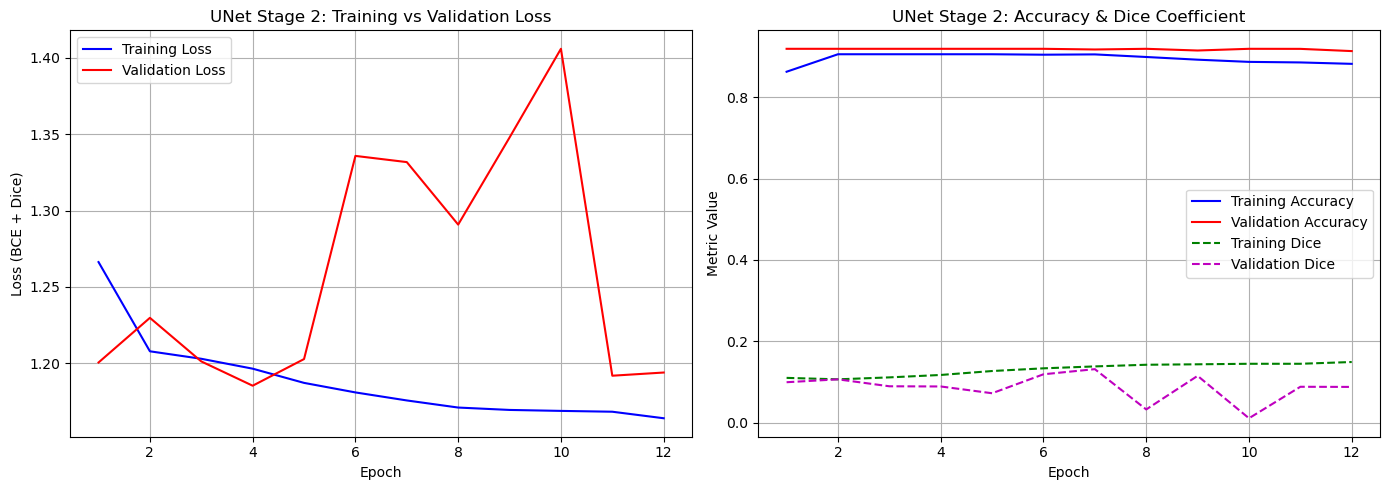


📊 Final Training Metrics:
   Training Loss:       1.1640
   Validation Loss:     1.1939
   Training Accuracy:   0.8818
   Validation Accuracy: 0.9131
   Training Dice:       0.1493
   Validation Dice:     0.0881


In [15]:
# Plot training history for UNet Stage 2
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(history_stage2.history['loss']) + 1)

# Plot 1: Loss
axes[0].plot(epochs_range, history_stage2.history['loss'], 'b-', label='Training Loss')
axes[0].plot(epochs_range, history_stage2.history['val_loss'], 'r-', label='Validation Loss')
axes[0].set_title('UNet Stage 2: Training vs Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (BCE + Dice)')
axes[0].legend()
axes[0].grid(True)

# Plot 2: Accuracy (binary_accuracy) and Dice Coefficient
axes[1].plot(epochs_range, history_stage2.history['binary_accuracy'], 'b-', label='Training Accuracy')
axes[1].plot(epochs_range, history_stage2.history['val_binary_accuracy'], 'r-', label='Validation Accuracy')
axes[1].plot(epochs_range, history_stage2.history['dice_coefficient'], 'g--', label='Training Dice')
axes[1].plot(epochs_range, history_stage2.history['val_dice_coefficient'], 'm--', label='Validation Dice')
axes[1].set_title('UNet Stage 2: Accuracy & Dice Coefficient')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Metric Value')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

# Print final metrics
print("\n📊 Final Training Metrics:")
print(f"   Training Loss:       {history_stage2.history['loss'][-1]:.4f}")
print(f"   Validation Loss:     {history_stage2.history['val_loss'][-1]:.4f}")
print(f"   Training Accuracy:   {history_stage2.history['binary_accuracy'][-1]:.4f}")
print(f"   Validation Accuracy: {history_stage2.history['val_binary_accuracy'][-1]:.4f}")
print(f"   Training Dice:       {history_stage2.history['dice_coefficient'][-1]:.4f}")
print(f"   Validation Dice:     {history_stage2.history['val_dice_coefficient'][-1]:.4f}")

In [ ]:
# Comprehensive Overfitting/Underfitting Analysis
import matplotlib.pyplot as plt
import numpy as np

print("="*60)
print("MODEL TRAINING ANALYSIS: OVERFITTING/UNDERFITTING CHECK")
print("="*60)

# Extract training history
train_loss = history_stage2.history['loss']
val_loss = history_stage2.history['val_loss']
train_acc = history_stage2.history['binary_accuracy']
val_acc = history_stage2.history['val_binary_accuracy']
train_dice = history_stage2.history['dice_coefficient']
val_dice = history_stage2.history['val_dice_coefficient']

epochs = range(1, len(train_loss) + 1)

# Create comprehensive analysis plot
fig = plt.figure(figsize=(18, 12))
gs = fig.add_gridspec(3, 2, hspace=0.3, wspace=0.3)

# 1. Loss Comparison
ax1 = fig.add_subplot(gs[0, 0])
ax1.plot(epochs, train_loss, 'b-o', label='Training Loss', linewidth=2, markersize=6)
ax1.plot(epochs, val_loss, 'r-s', label='Validation Loss', linewidth=2, markersize=6)
ax1.set_title('Loss: Training vs Validation', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Add gap annotation
final_gap_loss = abs(train_loss[-1] - val_loss[-1])
ax1.annotate(f'Final Gap: {final_gap_loss:.4f}', 
             xy=(len(epochs), train_loss[-1]), 
             xytext=(len(epochs)*0.7, max(train_loss)*0.8),
             fontsize=10, color='red',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
             arrowprops=dict(arrowstyle='->', color='red'))

# 2. Accuracy Comparison
ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(epochs, train_acc, 'b-o', label='Training Accuracy', linewidth=2, markersize=6)
ax2.plot(epochs, val_acc, 'r-s', label='Validation Accuracy', linewidth=2, markersize=6)
ax2.set_title('Accuracy: Training vs Validation', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)

# Add gap annotation
final_gap_acc = abs(train_acc[-1] - val_acc[-1])
ax2.annotate(f'Final Gap: {final_gap_acc:.4f}', 
             xy=(len(epochs), train_acc[-1]), 
             xytext=(len(epochs)*0.7, min(train_acc)*1.1),
             fontsize=10, color='red',
             bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5),
             arrowprops=dict(arrowstyle='->', color='red'))

# 3. Dice Coefficient Comparison
ax3 = fig.add_subplot(gs[1, 0])
ax3.plot(epochs, train_dice, 'g-o', label='Training Dice', linewidth=2, markersize=6)
ax3.plot(epochs, val_dice, 'm-s', label='Validation Dice', linewidth=2, markersize=6)
ax3.set_title('Dice Coefficient: Training vs Validation', fontsize=14, fontweight='bold')
ax3.set_xlabel('Epoch', fontsize=12)
ax3.set_ylabel('Dice Coefficient', fontsize=12)
ax3.legend(fontsize=11)
ax3.grid(True, alpha=0.3)

# 4. Gap Analysis Over Time
ax4 = fig.add_subplot(gs[1, 1])
loss_gaps = [abs(t - v) for t, v in zip(train_loss, val_loss)]
acc_gaps = [abs(t - v) for t, v in zip(train_acc, val_acc)]
dice_gaps = [abs(t - v) for t, v in zip(train_dice, val_dice)]

ax4.plot(epochs, loss_gaps, 'r-o', label='Loss Gap', linewidth=2, markersize=6)
ax4.plot(epochs, acc_gaps, 'b-s', label='Accuracy Gap', linewidth=2, markersize=6)
ax4.plot(epochs, dice_gaps, 'g-^', label='Dice Gap', linewidth=2, markersize=6)
ax4.set_title('Training-Validation Gap Over Time', fontsize=14, fontweight='bold')
ax4.set_xlabel('Epoch', fontsize=12)
ax4.set_ylabel('Absolute Gap', fontsize=12)
ax4.legend(fontsize=11)
ax4.grid(True, alpha=0.3)
ax4.axhline(y=0.05, color='orange', linestyle='--', label='Acceptable Gap (~0.05)', alpha=0.7)

# 5. Learning Rate Analysis (Loss Change)
ax5 = fig.add_subplot(gs[2, :])
loss_change = [0] + [val_loss[i] - val_loss[i-1] for i in range(1, len(val_loss))]
ax5.bar(epochs, loss_change, color=['green' if x < 0 else 'red' for x in loss_change], alpha=0.7)
ax5.set_title('Validation Loss Change Per Epoch (Negative = Improvement)', fontsize=14, fontweight='bold')
ax5.set_xlabel('Epoch', fontsize=12)
ax5.set_ylabel('Loss Change', fontsize=12)
ax5.axhline(y=0, color='black', linestyle='-', linewidth=1)
ax5.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Statistical Analysis
print("\n" + "="*60)
print("STATISTICAL ANALYSIS")
print("="*60)

# Calculate metrics
final_train_loss = train_loss[-1]
final_val_loss = val_loss[-1]
final_train_acc = train_acc[-1]
final_val_acc = val_acc[-1]
final_train_dice = train_dice[-1]
final_val_dice = val_dice[-1]

loss_gap_pct = (final_gap_loss / final_val_loss) * 100
acc_gap_pct = (final_gap_acc / final_val_acc) * 100

# Overfitting/Underfitting Detection
print("\n📊 Final Metrics:")
print(f"   Training Loss:     {final_train_loss:.4f}")
print(f"   Validation Loss:   {final_val_loss:.4f}")
print(f"   Loss Gap:          {final_gap_loss:.4f} ({loss_gap_pct:.2f}%)")
print(f"\n   Training Accuracy: {final_train_acc:.4f}")
print(f"   Validation Accuracy: {final_val_acc:.4f}")
print(f"   Accuracy Gap:      {final_gap_acc:.4f} ({acc_gap_pct:.2f}%)")
print(f"\n   Training Dice:     {final_train_dice:.4f}")
print(f"   Validation Dice:   {final_val_dice:.4f}")
print(f"   Dice Gap:          {abs(final_train_dice - final_val_dice):.4f}")

# Determine model state
print("\n" + "="*60)
print("DIAGNOSIS")
print("="*60)

if final_val_loss > 0.5 and final_val_acc < 0.7:
    status = "⚠️  UNDERFITTING"
    print(f"\n{status}")
    print("   The model has NOT learned the patterns well.")
    print("   Recommendations:")
    print("   - Increase model complexity (more layers/parameters)")
    print("   - Train for more epochs")
    print("   - Reduce regularization (dropout)")
    print("   - Check data quality and preprocessing")
elif loss_gap_pct > 20 or acc_gap_pct > 10:
    status = "⚠️  OVERFITTING"
    print(f"\n{status}")
    print("   The model has memorized training data but doesn't generalize well.")
    print("   Recommendations:")
    print("   - Add more training data or data augmentation")
    print("   - Increase dropout rate")
    print("   - Use early stopping")
    print("   - Add L2 regularization")
    print("   - Reduce model complexity")
elif loss_gaps[-1] > loss_gaps[len(loss_gaps)//2] * 1.5:
    status = "⚠️  STARTING TO OVERFIT"
    print(f"\n{status}")
    print("   The gap between training and validation is increasing.")
    print("   Recommendations:")
    print("   - Consider stopping training soon")
    print("   - Use the model from an earlier epoch")
    print("   - Implement early stopping for future training")
else:
    status = "✅ GOOD FIT"
    print(f"\n{status}")
    print("   The model is well-balanced and generalizes well.")
    print("   Training and validation metrics are close.")
    print("   The model is ready for deployment!")

print("\n" + "="*60)

EVALUATING UNET MODEL ON TEST SET


2026-01-18 07:30:11.124462: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


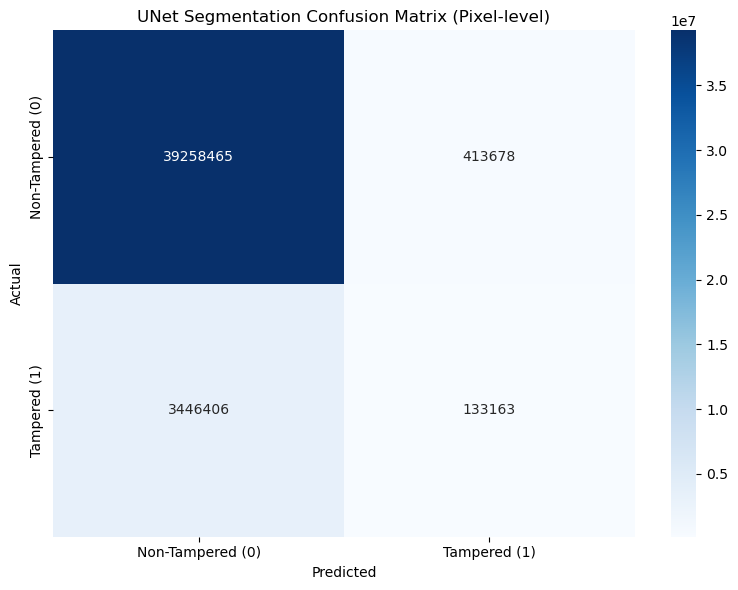


📊 Classification Report (Pixel-level):
              precision    recall  f1-score   support

Non-Tampered       0.92      0.99      0.95  39672143
    Tampered       0.24      0.04      0.06   3579569

    accuracy                           0.91  43251712
   macro avg       0.58      0.51      0.51  43251712
weighted avg       0.86      0.91      0.88  43251712


📈 Summary Metrics:
   True Negatives:  39,258,465
   False Positives: 413,678
   False Negatives: 3,446,406
   True Positives:  133,163
   Accuracy: 0.9108
   Precision: 0.2435
   Recall: 0.0372


In [17]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

# Evaluate UNet on test set and generate confusion matrix
print("="*60)
print("EVALUATING UNET MODEL ON TEST SET")
print("="*60)

y_true = []
y_pred = []

for tp_batch, mask_batch in test_paired_ds:
    # Get predictions
    pred_masks = unet_model.predict(tp_batch, verbose=0)
    
    # Flatten and binarize predictions (threshold 0.5)
    pred_binary = (pred_masks > 0.5).astype(np.int32).flatten()  # Changed to int32
    true_binary = mask_batch.numpy().astype(np.int32).flatten()  # Changed to int32
    
    y_true.extend(true_binary)
    y_pred.extend(pred_binary)

y_true = np.array(y_true, dtype=np.int32)  # Ensure integer type
y_pred = np.array(y_pred, dtype=np.int32)  # Ensure integer type

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Non-Tampered (0)', 'Tampered (1)'],
            yticklabels=['Non-Tampered (0)', 'Tampered (1)'])
plt.title('UNet Segmentation Confusion Matrix (Pixel-level)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

# Print classification report
print("\n📊 Classification Report (Pixel-level):")
print(classification_report(y_true, y_pred, target_names=['Non-Tampered', 'Tampered']))

# Print summary metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Summary Metrics:")
print(f"   True Negatives:  {tn:,}")
print(f"   False Positives: {fp:,}")
print(f"   False Negatives: {fn:,}")
print(f"   True Positives:  {tp:,}")
print(f"   Accuracy: {(tp + tn) / (tp + tn + fp + fn):.4f}")
print(f"   Precision: {tp / (tp + fp) if (tp + fp) > 0 else 0:.4f}")
print(f"   Recall: {tp / (tp + fn) if (tp + fn) > 0 else 0:.4f}")

GENERATING 5 SAMPLE PREDICTIONS

Sample 1:
   File: Tp_S_NRN_S_N_ani20037_ani20037_02080.tif
   Prediction: AUTHENTIC ✗
   Tampered pixels: 0 / 50176
   Tampered percentage: 0.00%

Sample 2:
   File: Tp_S_NNN_S_B_pla00014_pla00014_20064.jpg
   Prediction: TAMPERED ✓
   Tampered pixels: 10 / 50176
   Tampered percentage: 0.02%

Sample 3:
   File: Tp_D_NRN_M_B_cha10162_nat10142_12254.jpg
   Prediction: TAMPERED ✓
   Tampered pixels: 151 / 50176
   Tampered percentage: 0.30%

Sample 4:
   File: Tp_S_NNN_S_B_nat00050_nat00050_00968.tif
   Prediction: AUTHENTIC ✗
   Tampered pixels: 0 / 50176
   Tampered percentage: 0.00%

Sample 5:
   File: Tp_S_NNN_S_B_ani00014_ani00014_20058.jpg
   Prediction: AUTHENTIC ✗
   Tampered pixels: 0 / 50176
   Tampered percentage: 0.00%


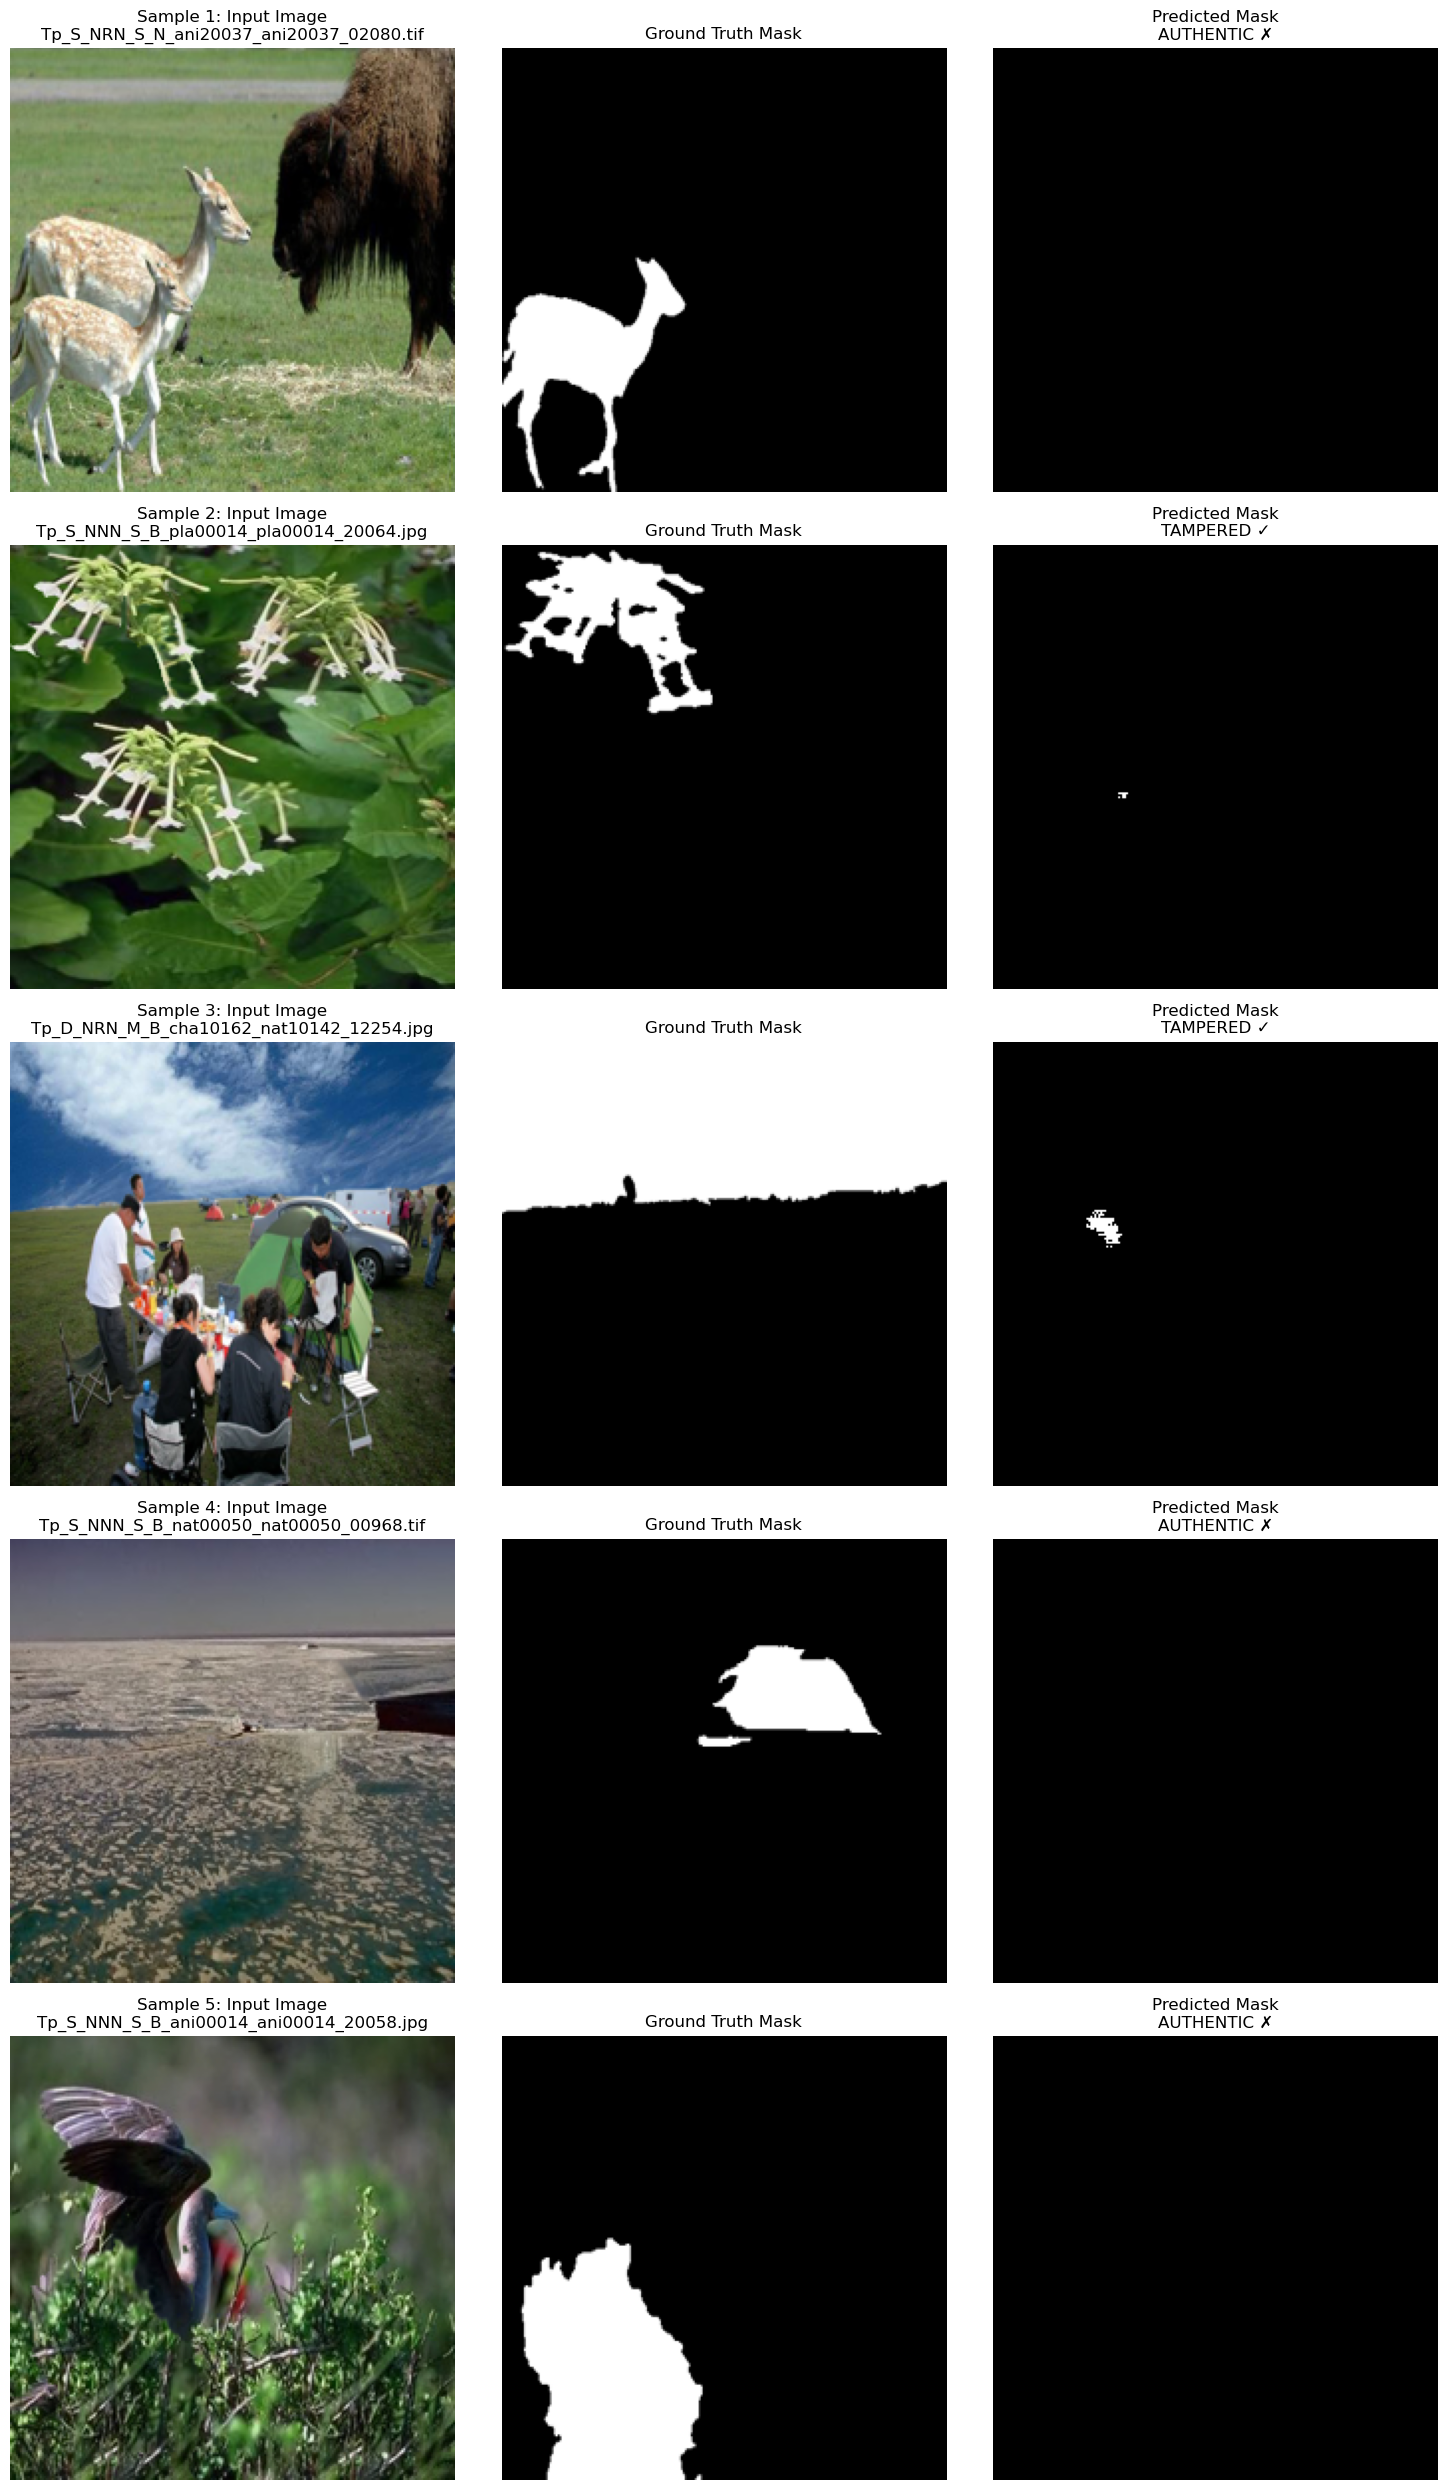


✅ SAMPLE PREDICTIONS COMPLETE


In [19]:
import random

# Generate sample predictions with visualizations

# Select random samples from test set
num_samples = 5
print("="*60)
print(f"GENERATING {num_samples} SAMPLE PREDICTIONS")
print("="*60)

# Get all test image paths
test_tp_paths = get_paths('test', 'Tp')
test_mask_dir = BASE_PATH / 'test' / 'Mask'

# Randomly select samples
sample_indices = random.sample(range(len(test_tp_paths)), num_samples)
sample_paths = [test_tp_paths[i] for i in sample_indices]

# Create figure
fig, axes = plt.subplots(num_samples, 3, figsize=(15, 5*num_samples))
if num_samples == 1:
    axes = axes.reshape(1, -1)

for idx, tp_path in enumerate(sample_paths):
    # Load tampered image
    tp_img = load_single_image(tp_path, IMAGE_SIZE)
    
    # Find corresponding mask
    tp_basename = Path(tp_path).stem
    mask_name = f"{tp_basename}_gt.png"
    mask_path = test_mask_dir / mask_name
    
    # Load ground truth mask
    if mask_path.exists():
        mask_img = load_single_image(str(mask_path), IMAGE_SIZE)
        if mask_img.shape[-1] == 3:
            mask_img = mask_img[:, :, 0:1]  # Convert to grayscale
    else:
        mask_img = np.zeros((IMAGE_SIZE, IMAGE_SIZE, 1))
    
    # Predict mask using UNet
    pred_mask = unet_model.predict(np.expand_dims(tp_img, axis=0), verbose=0)[0]
    
    # Binary prediction
    pred_binary = (pred_mask > 0.5).astype(np.float32)
    
    # Check if tampered (if any pixel is predicted as tampered)
    is_tampered = np.max(pred_binary) > 0
    
    # Plot
    axes[idx, 0].imshow(tp_img)
    axes[idx, 0].set_title(f'Sample {idx+1}: Input Image\n{Path(tp_path).name}')
    axes[idx, 0].axis('off')
    
    axes[idx, 1].imshow(mask_img.squeeze(), cmap='gray')
    axes[idx, 1].set_title('Ground Truth Mask')
    axes[idx, 1].axis('off')
    
    axes[idx, 2].imshow(pred_binary.squeeze(), cmap='gray')
    tamper_status = "TAMPERED ✓" if is_tampered else "AUTHENTIC ✗"
    axes[idx, 2].set_title(f'Predicted Mask\n{tamper_status}')
    axes[idx, 2].axis('off')
    
    # Print detailed info
    print(f"\nSample {idx+1}:")
    print(f"   File: {Path(tp_path).name}")
    print(f"   Prediction: {tamper_status}")
    print(f"   Tampered pixels: {np.sum(pred_binary):.0f} / {IMAGE_SIZE*IMAGE_SIZE}")
    print(f"   Tampered percentage: {(np.sum(pred_binary)/(IMAGE_SIZE*IMAGE_SIZE)*100):.2f}%")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ SAMPLE PREDICTIONS COMPLETE")
print("="*60)

ERROR LEVEL ANALYSIS (ELA) FOR 3 IMAGES

Sample 1: Tp_D_CNN_M_N_txt00054_txt00050_10375.tif
   Image shape: (256, 384, 3)
   Has tampering mask: True
   Edge density: 35.82%
   Mean edge strength: 88.32
   Max edge strength: 584.00
   Intensity range: [0, 254]

Sample 2: Tp_S_NNN_M_N_txt00032_txt00032_10341.tif
   Image shape: (256, 384, 3)
   Has tampering mask: True
   Edge density: 13.06%
   Mean edge strength: 22.41
   Max edge strength: 378.00
   Intensity range: [0, 239]

Sample 3: Tp_D_NRD_S_B_nat20039_arc20055_02239.tif
   Image shape: (317, 550, 3)
   Has tampering mask: True
   Edge density: 14.48%
   Mean edge strength: 23.69
   Max edge strength: 599.00
   Intensity range: [0, 232]


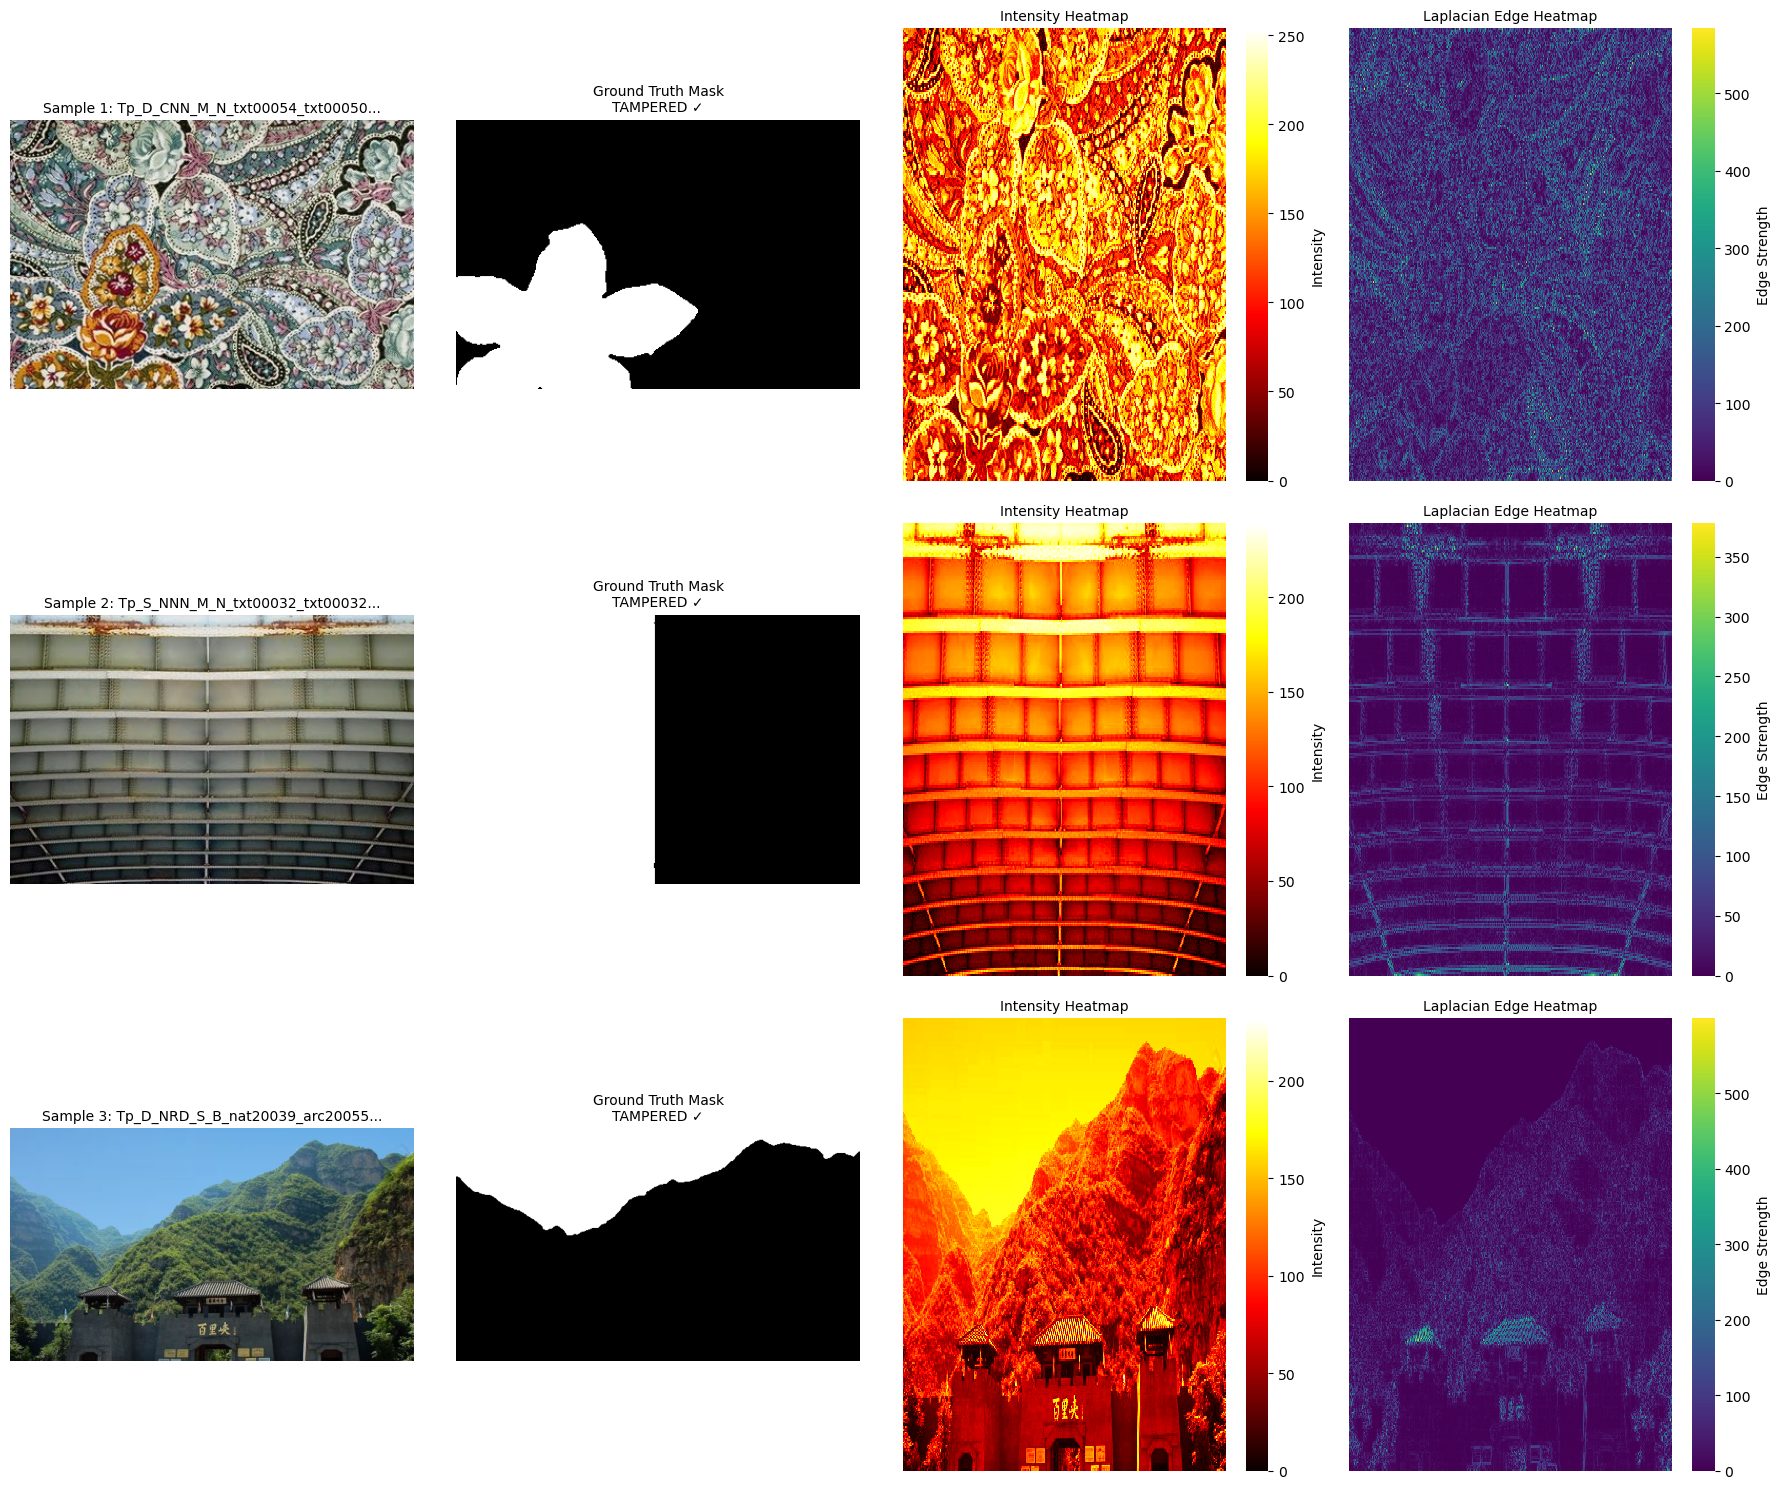


✅ HEATMAP ANALYSIS COMPLETE

💡 Interpretation:
   - Intensity Heatmap: Shows pixel brightness distribution
   - Laplacian Heatmap: Highlights edges and discontinuities
   - Bright spots in Laplacian = sharp transitions (potential tampering)
   - High edge density may indicate splicing or copy-paste artifacts


In [23]:
# Error Level Analysis (ELA) and Heatmap for multiple tampered images
import cv2
import seaborn as sns

# Select multiple tampered images for analysis
num_freq_samples = 3
print("="*60)
print(f"ERROR LEVEL ANALYSIS (ELA) FOR {num_freq_samples} IMAGES")
print("="*60)

# Get test tampered images
test_tp_dir = BASE_PATH / 'test' / 'Tp'
test_mask_dir = BASE_PATH / 'test' / 'Mask'
all_tp_images = sorted(list(test_tp_dir.glob("*.tif")))

# Select samples (you can change indices to analyze specific images)
selected_images = random.sample(all_tp_images, min(num_freq_samples, len(all_tp_images)))

# Create figure with 4 columns: Original, Mask, Grayscale Heatmap, Edge Detection
fig, axes = plt.subplots(num_freq_samples, 4, figsize=(18, 5*num_freq_samples))
if num_freq_samples == 1:
    axes = axes.reshape(1, -1)

for idx, img_path in enumerate(selected_images):
    # Load the image
    img = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # Load corresponding mask
    tp_basename = img_path.stem
    mask_name = f"{tp_basename}_gt.png"
    mask_path = test_mask_dir / mask_name
    
    if mask_path.exists():
        mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
        has_mask = True
    else:
        mask = np.zeros_like(img_gray)
        has_mask = False
    
    # Compute edge detection (Canny)
    edges = cv2.Canny(img_gray, 100, 200)
    
    # Compute Laplacian (highlights areas with rapid intensity change - tampering artifacts)
    laplacian = cv2.Laplacian(img_gray, cv2.CV_64F)
    laplacian_abs = np.abs(laplacian)
    
    # Plot 1: Original image
    axes[idx, 0].imshow(img_rgb)
    axes[idx, 0].set_title(f'Sample {idx+1}: {img_path.name[:30]}...', fontsize=10)
    axes[idx, 0].axis('off')
    
    # Plot 2: Ground truth mask
    axes[idx, 1].imshow(mask, cmap='gray')
    mask_status = "TAMPERED ✓" if has_mask and np.max(mask) > 0 else "No Mask"
    axes[idx, 1].set_title(f'Ground Truth Mask\n{mask_status}', fontsize=10)
    axes[idx, 1].axis('off')
    
    # Plot 3: Intensity Heatmap
    sns.heatmap(img_gray, cmap='hot', ax=axes[idx, 2], cbar=True, 
                square=False, xticklabels=False, yticklabels=False,
                cbar_kws={'label': 'Intensity'})
    axes[idx, 2].set_title('Intensity Heatmap', fontsize=10)
    
    # Plot 4: Laplacian Heatmap (tampering detection)
    sns.heatmap(laplacian_abs, cmap='viridis', ax=axes[idx, 3], cbar=True,
                square=False, xticklabels=False, yticklabels=False,
                cbar_kws={'label': 'Edge Strength'})
    axes[idx, 3].set_title('Laplacian Edge Heatmap', fontsize=10)
    
    # Print statistics
    edge_density = np.sum(edges > 0) / edges.size
    laplacian_mean = np.mean(laplacian_abs)
    laplacian_max = np.max(laplacian_abs)
    
    print(f"\nSample {idx+1}: {img_path.name}")
    print(f"   Image shape: {img_rgb.shape}")
    print(f"   Has tampering mask: {has_mask}")
    print(f"   Edge density: {edge_density*100:.2f}%")
    print(f"   Mean edge strength: {laplacian_mean:.2f}")
    print(f"   Max edge strength: {laplacian_max:.2f}")
    print(f"   Intensity range: [{img_gray.min()}, {img_gray.max()}]")

plt.tight_layout()
plt.show()

print("\n" + "="*60)
print("✅ HEATMAP ANALYSIS COMPLETE")
print("="*60)
print("\n💡 Interpretation:")
print("   - Intensity Heatmap: Shows pixel brightness distribution")
print("   - Laplacian Heatmap: Highlights edges and discontinuities")
print("   - Bright spots in Laplacian = sharp transitions (potential tampering)")
print("   - High edge density may indicate splicing or copy-paste artifacts")